# Trabalho 04 — Conversão de Profundidade de Bits
## PGM 8 bits (0–255) → 5 bits (0–31)

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> Converter a imagem `EntradaEscalaCinza.pgm` (8 bits em escala de cinza, 0–255)
> para 5 bits de intensidade.
>
> *Obs.: 8 bits significa valores de 0 a 255, e 5 bits significa valores de 0 a
> 31 — ou seja, precisa ser desenvolvido um fator de conversão.*

### Plano de trabalho

1. Ler o arquivo PGM de entrada com parser próprio, sem bibliotecas de imagem.
2. Caracterizar a imagem: dimensões, `maxval`, faixa dinâmica real, histograma.
3. Deduzir o fator de conversão e implementar **duas** estratégias de quantização.
4. Comparar as duas quantitativamente (MSE, PSNR, viés, erro máximo).
5. Gravar o resultado como PGM P2 válido com `maxval = 31`.
6. Avaliar visualmente a degradação (falso contorno / *banding*).

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### O formato PGM P2

O PGM (*Portable GrayMap*) é o membro da família PBM destinado a imagens em tons
de cinzento. Na variante ASCII o magic number é **P2**; na binária, **P5**.

Estrutura do cabeçalho, com os campos separados por espaço em branco:

1. Magic number `P2`
2. Largura, em píxeis
3. Altura, em píxeis
4. **`maxval`** — valor máximo dos tons de cinzento
5. Os `largura × altura` valores de intensidade

Diferente do PPM, aqui há **um único valor por píxel** (a intensidade luminosa),
não três. A apostila descreve essa representação como o caso em que "não há
tabela de cores" e "cada ponto da matriz é uma intensidade luminosa".

O varrimento é linha a linha, de cima para baixo, e da esquerda para a direita
dentro de cada linha.

### Profundidade de bits

A **profundidade** é quantos bits são reservados para cada píxel, e determina
quantos níveis distintos podem ser representados:

| Profundidade | Níveis   | Intervalo | `maxval` |
|--------------|----------|-----------|----------|
| 8 bits       | 2⁸ = 256 | 0 … 255   | 255      |
| 5 bits       | 2⁵ = 32  | 0 … 31    | 31       |

Reduzir de 8 para 5 bits significa **descartar informação**: 256 níveis de
entrada precisam ser mapeados em apenas 32 de saída. Trata-se portanto de uma
transformação **irreversível e com perda** — 8 níveis de entrada colapsam em
cada nível de saída.

O ganho é de espaço: em representação binária, cada píxel passaria de 1 byte
para 5 bits, uma redução de 37,5%.

In [6]:
from multiprocessing import util
from os import write
#Bibliotecas e configurações

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

ARQUIVO_ENTRADA = ENTRADA / "EntradaEscalaCinza.pgm"

#Limite de coluna das variantes ASCII, conforme especificação PBM

LIMITE_COLUNA = 70

#Profundidade de origem e destino
BITS_ORIGEM, BITS_DESTINO = 8, 5
MAXVAL_ORIGEM = 2 ** BITS_ORIGEM - 1
MAXVAL_DESTINO = 2 ** BITS_DESTINO - 1

print(f"Entrada existe : {ARQUIVO_ENTRADA.exists()}")
print(f"Caminho        : {ARQUIVO_ENTRADA}")
print(f"{BITS_ORIGEM} bits -> maxval {MAXVAL_ORIGEM} ({MAXVAL_ORIGEM + 1} níveis)")
print(f"{BITS_DESTINO} bits -> maxval {MAXVAL_DESTINO} ({MAXVAL_DESTINO + 1} níveis)")

Entrada existe : True
Caminho        : /home/igorkg/PycharmProjects/TrabalhoRGBProcessamentoDigitalDeImagem/TrabalhoPGM5bits/entrada/EntradaEscalaCinza.pgm
8 bits -> maxval 255 (256 níveis)
5 bits -> maxval 31 (32 níveis)


## 2. Leitura do arquivo

Reaproveito a abordagem da atividade anterior: tratar o arquivo como um **fluxo
de tokens**, não como linhas estruturadas. A especificação permite qualquer
combinação de espaços, TABs, CRs e LFs como separador, e permite comentários em
qualquer posição — um parser que assumisse "cabeçalho em 3 linhas" quebraria em
arquivos válidos.

Essa escolha se paga imediatamente neste arquivo: ele usa terminadores **CRLF**
(`\r\n`) e traz **um valor por linha**. Como `str.split()` sem argumentos trata
qualquer *whitespace* como separador — incluindo o `\r` — o parser funciona sem
nenhum tratamento especial.

In [7]:
def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'. """
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token

def ler_png_p2(caminho):
    """
    Lê um arquivo PGM tipo P2 e devolve (matriz 2D, maxval).

    A matriz tem shape (altura, largura), com um valor de intensidade por píxel.
    """
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P2":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado P2)")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        esperados = largura * altura

        dados = np.fromiter(map(int, it), dtype=np.int32, count=esperados)

    if dados.size != esperados:
        raise ValueError(f"Arquivo PGM com {dados.size} valores, esperados {esperados}")
    return dados.reshape(altura, largura), maxval

In [8]:
# --- Leitura e caracterização da imagem de entrada ---

original, maxval_lido = ler_png_p2(ARQUIVO_ENTRADA)
altura, largura = original.shape

print("CARACTERIZAÇÃO DA IMAGEM DE ENTRADA")
print("-" * 46)
print(f"Dimensões          : {largura} x {altura}")
print(f"Total de píxeis    : {original.size:,}")
print(f"maxval declarado   : {maxval_lido}")
print(f"Profundidade       : {BITS_ORIGEM} bits")
print()
print(f"Valor mínimo real  : {original.min()}")
print(f"Valor máximo real  : {original.max()}")
print(f"Média              : {original.mean():.2f}")
print(f"Desvio padrão      : {original.std():.2f}")
print(f"Níveis distintos   : {np.unique(original).size} de {maxval_lido + 1} possíveis")
print()
print(f"Tamanho em disco   : {ARQUIVO_ENTRADA.stat().st_size / 1024**2:.2f} MB")

CARACTERIZAÇÃO DA IMAGEM DE ENTRADA
----------------------------------------------
Dimensões          : 800 x 800
Total de píxeis    : 640,000
maxval declarado   : 255
Profundidade       : 8 bits

Valor mínimo real  : 13
Valor máximo real  : 243
Média              : 115.93
Desvio padrão      : 53.01
Níveis distintos   : 231 de 256 possíveis

Tamanho em disco   : 2.86 MB


### Observação sobre a faixa dinâmica

A imagem **não ocupa toda a faixa** de 0 a 255. Isso é relevante para a escolha
do fator de conversão e vale registrar antes de prosseguir.

Existem duas leituras possíveis do problema:

**Conversão absoluta** — mapear o intervalo teórico `[0, 255]` em `[0, 31]`.
Preserva a relação entre a imagem e a escala de cinzas padrão: um píxel de valor
128 (cinza médio) continua sendo cinza médio depois da conversão.

**Conversão com esticamento de contraste** — mapear o intervalo *observado*
`[mín, máx]` em `[0, 31]`. Aproveitaria os 32 níveis integralmente, mas
**alteraria o brilho e o contraste da imagem**, que é uma operação distinta de
"converter a profundidade de bits".

Adoto a **conversão absoluta**, porque o enunciado pede conversão de profundidade
e não realce de contraste. O esticamento seria uma transformação de
pré-processamento com outro objetivo, e misturá-la aqui mascararia o efeito que
se quer observar.

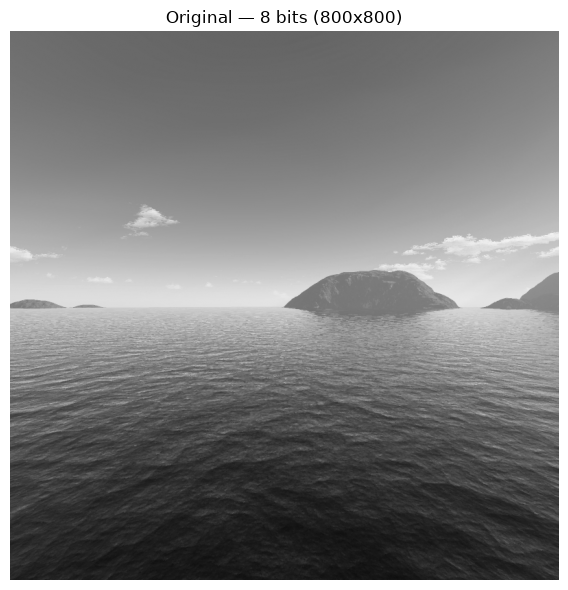

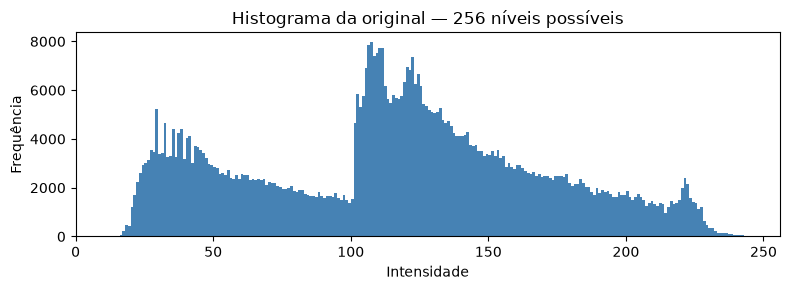

In [9]:
# --- Utilitários de visualização ---

def exibir(imagem, maxval, titulo, tamanho = 5):
    """Exibe em escala de cinza. vmin/vmax fixos evitam normalização automática."""
    plt.figure(figsize=(tamanho, tamanho))
    plt.imshow(imagem, cmap="gray", vmin=0, vmax=maxval)
    plt.title(titulo)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def histograma(imagem, maxval, titulo, cor="steelblue"):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(imagem.ravel(), bins=maxval + 1, range=(0, maxval + 1),
            color=cor, edgecolor="none")
    ax.set_title(titulo)
    ax.set_xlabel("Intensidade")
    ax.set_ylabel("Frequência")
    ax.set_xlim(0, maxval + 1)
    plt.tight_layout()
    plt.show()

exibir(original, MAXVAL_ORIGEM, f"Original — {BITS_ORIGEM} bits ({largura}x{altura})", tamanho=6)
histograma(original, MAXVAL_ORIGEM, f"Histograma da original — {MAXVAL_ORIGEM + 1} níveis possíveis")

## 3. O fator de conversão

Este é o núcleo da atividade. Há duas formulações defensáveis, e elas **não são
equivalentes**.

### Método A — descarte dos bits menos significativos

Interpretação literal de "reduzir a profundidade": ficar apenas com os 5 bits
mais significativos e jogar fora os 3 últimos.

    novo = antigo >> 3        (equivale a antigo // 8)

O fator aqui é `2^(8-5) = 2^3 = 8`. Cada grupo de 8 valores consecutivos da
entrada colapsa em um único valor de saída:

| Entrada  | Saída |
|----------|-------|
| 0 … 7    | 0     |
| 8 … 15   | 1     |
| …        | …     |
| 248 … 255| 31    |

É a operação mais barata possível — um deslocamento de bits — e é o que o
hardware efetivamente faz. Mas usa **truncamento**, ou seja, sempre arredonda
para baixo, o que introduz um **viés sistemático de escurecimento**.

### Método B — escala proporcional com arredondamento

Interpretação como regra de três entre os intervalos:

    novo = round(antigo × 31 / 255)

O fator é `31/255 ≈ 0,12157`. Mapeia os extremos exatamente (0→0, 255→31) e usa
**arredondamento ao mais próximo** em vez de truncamento, o que elimina o viés.

### Qual usar?

O enunciado fala em "desenvolver um fator de conversão", o que aponta para o
método B — e ele é de fato o melhor em erro médio. Implemento **os dois** e
comparo numericamente; o método B é o adotado como resposta oficial.

### Inversa (reexpansão)

Para comparar as duas imagens visualmente e medir o erro, é preciso trazer o
resultado de volta para a escala de 8 bits:

    reexpandido = round(novo × 255 / 31)

Isso **não recupera** a informação perdida — apenas devolve a imagem quantizada
à mesma escala da original, para que a subtração faça sentido.

In [10]:
def quantizar_descarte(imagem, bits_origem = BITS_ORIGEM, bits_destino = BITS_DESTINO):
    """Método A: descarta os (bits_origem - bits_destino) bits menos significativos."""
    deslocamento = bits_origem - bits_destino
    return (imagem.astype(np.int32) >> deslocamento).astype(np.int32)

def quantizar_proporcional(imagem, maxval_origem = MAXVAL_ORIGEM, maxval_destino = MAXVAL_DESTINO):
    """Método B: escala proporcional com arredondamento ao inteiro mais próximo."""
    fator = maxval_destino / maxval_origem
    return np.rint(imagem.astype(np.float64) * fator).astype(np.int32)

def reexpandir (imagem, maxval_origem = MAXVAL_ORIGEM, maxval_destino = MAXVAL_DESTINO):
    """Traz a imagem quantizada de volta à escala de 8 bits, para comparação."""
    fator = maxval_origem / maxval_destino
    return np.rint(imagem.astype(np.float64) * fator).astype(np.int32)

# Demonstração do mapeamento em valores selecionados
print(f"Fator método A : 2^{BITS_ORIGEM - BITS_DESTINO} = "
      f"{2 ** (BITS_ORIGEM - BITS_DESTINO)}  (divisor)")
print(f"Fator método B : {MAXVAL_DESTINO}/{MAXVAL_ORIGEM} = "
      f"{MAXVAL_DESTINO / MAXVAL_ORIGEM:.5f}  (multiplicador)\n")

amostras = np.array([0, 1, 7, 8, 100, 127, 128, 200, 247, 248, 254, 255])
print(f"{'8 bits':>8}{'A (>>3)':>10}{'B (prop)':>10}{'difere':>9}")
print("-" * 37)
for v in amostras:
    a = int(quantizar_descarte(np.array([v]))[0])
    b = int(quantizar_proporcional(np.array([v]))[0])
    print(f"{v:>8}{a:>10}{b:>10}{'  <--' if a != b else '':>9}")

Fator método A : 2^3 = 8  (divisor)
Fator método B : 31/255 = 0.12157  (multiplicador)

  8 bits   A (>>3)  B (prop)   difere
-------------------------------------
       0         0         0         
       1         0         0         
       7         0         1      <--
       8         1         1         
     100        12        12         
     127        15        15         
     128        16        16         
     200        25        24      <--
     247        30        30         
     248        31        30      <--
     254        31        31         
     255        31        31         


In [11]:
# --- Aplicar os dois métodos à imagem inteira ---

quant_a = quantizar_descarte(original)
quant_b = quantizar_proporcional(original)

for nome, q in (("A (descarte)", quant_a), ("B (Proporcional)", quant_b)):
    assert q.min() >= 0 and q.max() <= MAXVAL_DESTINO, "Valor fora de [0, 31]"
    print(f"Método {nome:<18} range [{q.min()}, {q.max()}]  "
          f"níveis usados: {np.unique(q).size}/{MAXVAL_DESTINO + 1}")

concordancia = (quant_a == quant_b).mean() * 100
print(f"\nOs dois métodos concordam em {concordancia:.2f}% dos píxeis.")

Método A (descarte)       range [1, 30]  níveis usados: 30/32
Método B (Proporcional)   range [2, 30]  níveis usados: 29/32

Os dois métodos concordam em 85.82% dos píxeis.


## 4. Avaliação quantitativa do erro

Para decidir entre os métodos com critério objetivo, reexpando cada resultado
para 8 bits e comparo com a original. Quatro métricas:

- **MSE** (*Mean Squared Error*) — erro quadrático médio. Quanto menor, melhor.
- **PSNR** (*Peak Signal-to-Noise Ratio*) — em decibéis, quanto maior, melhor:

      PSNR = 10 · log₁₀(255² / MSE)

- **Erro máximo** — o pior desvio individual, em níveis de 8 bits.
- **Viés** — média do erro *com sinal*. Um viés próximo de zero indica que o
  método não escurece nem clareia sistematicamente a imagem.

O viés é a métrica que separa os dois métodos com mais clareza, e é a
consequência direta da escolha entre truncar e arredondar.

In [12]:
def metricas (original, quantizada, maxval_origem = MAXVAL_ORIGEM):
    """Calcula MSE, PSNR, erro máximo e viés após reexpandir para 8 bits."""
    rec = reexpandir(quantizada)
    erro = original.astype(np.float64) - rec.astype(np.float64)

    mse = float((erro ** 2).mean())
    psnr = 10 * np.log10(maxval_origem ** 2 / mse) if mse > 0 else float("inf")

    return {"mse": mse, "psnr": psnr,
            "erro_max": float(np.abs(erro).max()),
            "vies": float(erro.mean())}

resultados = {"A (descarte >> 3)": metricas(original, quant_a),
              "B (Proporcional)": metricas(original, quant_b)}

print(f"{'Método':<20}{'MSE':>9}{'PSNR (dB)':>12}{'Erro máx':>11}{'Viés':>10}")
print("-" * 62)
for nome, m in resultados.items():
    print(f"{nome:<20}{m['mse']:>9.3f}{m['psnr']:>12.2f}"
          f"{m['erro_max']:>11.0f}{m['vies']:>+10.3f}")

melhor = min(resultados, key=lambda k: resultados[k]["mse"])
print(f"\nMenor erro: método {melhor}")

Método                    MSE   PSNR (dB)   Erro máx      Viés
--------------------------------------------------------------
A (descarte >> 3)       8.001       39.10          7    +0.337
B (Proporcional)        5.832       40.47          4    +0.018

Menor erro: método B (Proporcional)


### Interpretação

O método proporcional apresenta MSE menor, erro máximo menor e viés praticamente
nulo. A razão é estrutural, não acidental:

- O **truncamento** do método A comete erro no intervalo `[0, +7]` — sempre para
  o mesmo lado. Na média, escurece a imagem.
- O **arredondamento** do método B comete erro em `[-4, +4]` — distribuído
  simetricamente. Os desvios se cancelam.

Adoto o **método B** como resultado oficial da atividade. O método A fica
registrado como referência, por ser a interpretação literal em nível de bits e
por ser o que se implementaria em hardware, onde um deslocamento custa muito
menos que uma multiplicação em ponto flutuante.

In [13]:
# --- Escritor PGM P2 ---

def calcular_valores_por_linha(maxval, limite_coluna=LIMITE_COLUNA):
    """Maior quantidade de valores por linha respeitando o limite de colunas."""
    largura_token = len(str(maxval))
    return max(1, (limite_coluna + 1) // (largura_token + 1))


def escrever_pgm_p2(caminho, imagem, maxval, comentario=None,
                    limite_coluna=LIMITE_COLUNA):
    """Grava uma matriz 2D de inteiros como arquivo PGM tipo P2 (ASCII)."""
    imagem = np.asarray(imagem)

    if imagem.ndim != 2:
        raise ValueError(f"Esperada matriz 2D, recebido shape {imagem.shape}")
    if imagem.min() < 0 or imagem.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    altura, largura = imagem.shape
    n = calcular_valores_por_linha(maxval, limite_coluna)
    plano = imagem.reshape(-1).tolist()

    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write("P2\n")
        if comentario:
            f.write(f"# {comentario}\n")
        f.write(f"{largura} {altura}\n")
        f.write(f"{maxval}\n")

        linhas = [" ".join(map(str, plano[i:i + n]))
                  for i in range(0, len(plano), n)]
        f.write("\n".join(linhas))
        f.write("\n")

    return caminho


def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            comprimento = len(linha.rstrip("\n"))
            if comprimento > limite:
                raise AssertionError(f"Linha {numero}: {comprimento} caracteres")
            maior = max(maior, comprimento)
    return maior


print(f"maxval {MAXVAL_DESTINO}: {calcular_valores_por_linha(MAXVAL_DESTINO)} valores por linha")

maxval 31: 23 valores por linha


In [14]:
# --- Gravação do resultado oficial (método B, maxval = 31) ---

SAIDA_5BITS = SAIDA / 'SaidaEscalaCinza_5bits.pgm'
escrever_pgm_p2(SAIDA_5BITS, quant_b, MAXVAL_DESTINO,
               comentario=(f"convertido de {BITS_ORIGEM} para {BITS_DESTINO} bits - "
                f"fator {MAXVAL_DESTINO}/{MAXVAL_ORIGEM} com arredondamento")
                )

# Validação: round-trip completo
lida, maxval_saida = ler_png_p2(SAIDA_5BITS)
assert maxval_saida == MAXVAL_DESTINO
assert np.array_equal(lida, quant_b)

tam_entrada = ARQUIVO_ENTRADA.stat().st_size
tam_saida = SAIDA_5BITS.stat().st_size

print(f"Arquivo gravado : {SAIDA_5BITS.name}")
print(f"maxval          : {maxval_saida}")
print(f"Round-trip      : OK (idêntico à matriz quantizada)")
print(f"Maior linha     : {verificar_limite_colunas(SAIDA_5BITS)} caracteres")
print()
print(f"Entrada (ASCII) : {tam_entrada / 1024**2:.2f} MB")
print(f"Saída   (ASCII) : {tam_saida / 1024**2:.2f} MB")
print(f"Redução         : {(1 - tam_saida / tam_entrada) * 100:.1f}%")
print()
print("Primeiras linhas:")
print("-" * 50)
with open(SAIDA_5BITS) as f:
    for _ in range(6):
        print(f.readline().rstrip())

Arquivo gravado : SaidaEscalaCinza_5bits.pgm
maxval          : 31
Round-trip      : OK (idêntico à matriz quantizada)
Maior linha     : 68 caracteres

Entrada (ASCII) : 2.86 MB
Saída   (ASCII) : 1.67 MB
Redução         : 41.6%

Primeiras linhas:
--------------------------------------------------
P2
# convertido de 8 para 5 bits - fator 31/255 com arredondamento
800 800
31
13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13
13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13


### Nota sobre a redução de tamanho

A redução observada no arquivo **ASCII** vem do encurtamento dos tokens: valores
de até 3 dígitos passam a ter no máximo 2. Não é a redução "real" da conversão.

A economia efetiva da conversão de profundidade só aparece em representação
**binária**, onde 8 bits por píxel virariam 5 — uma redução de 37,5%. Na prática,
o formato P5 armazena 1 byte por píxel independentemente do `maxval`, de modo que
extrair essa economia exigiria empacotar os valores manualmente (8 píxeis de
5 bits em 5 bytes), o que o formato PGM não prevê.

Também gravo abaixo uma versão **reexpandida para `maxval = 255`**. Ela não é o
entregável — contém apenas 32 níveis distintos, sendo genuinamente uma imagem de
5 bits — mas serve para visualizadores que normalizam mal arquivos com `maxval`
não padrão, e permite abrir as duas imagens lado a lado na mesma escala.

In [15]:
# --- Versão auxiliar reexpandida para maxval 255 (apenas para visualização) ---

SAIDA_REEXP = SAIDA / "SaidaEscalaCinza_5bits_reexpandida255.pgm"
quant_b_reexp = reexpandir(quant_b)

escrever_pgm_p2(
    SAIDA_REEXP, quant_b_reexp, MAXVAL_ORIGEM,
    comentario="5 bits reexpandidos para maxval 255 - apenas para visualizacao"
)

print(f"Arquivo    : {SAIDA_REEXP.name}")
print(f"maxval     : {MAXVAL_ORIGEM}")
print(f"Níveis distintos: {np.unique(quant_b_reexp).size} "
      f"(confirma que continua sendo uma imagem de {BITS_DESTINO} bits)")

Arquivo    : SaidaEscalaCinza_5bits_reexpandida255.pgm
maxval     : 255
Níveis distintos: 29 (confirma que continua sendo uma imagem de 5 bits)


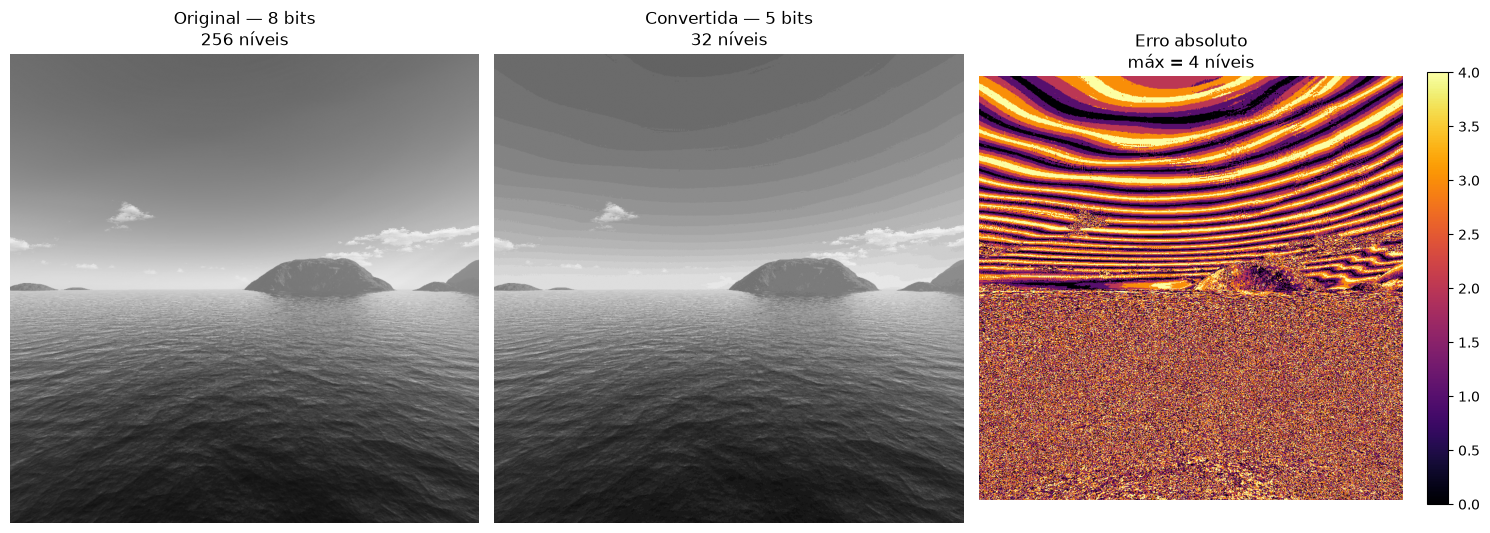

In [16]:
# --- Comparação visual lado a lado ---

fig, eixos = plt.subplots(1, 3, figsize=(15, 5.5))

eixos[0].imshow(original, cmap="gray", vmin=0, vmax=MAXVAL_ORIGEM)
eixos[0].set_title(f"Original — {BITS_ORIGEM} bits\n{MAXVAL_ORIGEM + 1} níveis")

eixos[1].imshow(quant_b, cmap="gray", vmin=0, vmax=MAXVAL_DESTINO)
eixos[1].set_title(f"Convertida — {BITS_DESTINO} bits\n{MAXVAL_DESTINO + 1} níveis")

diferenca = np.abs(original - quant_b_reexp)
im = eixos[2].imshow(diferenca, cmap="inferno")
eixos[2].set_title(f"Erro absoluto\nmáx = {diferenca.max():.0f} níveis")
fig.colorbar(im, ax=eixos[2], fraction=0.046)

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

Recorte em (linha=0, coluna=200), desvio padrão local = 4.17


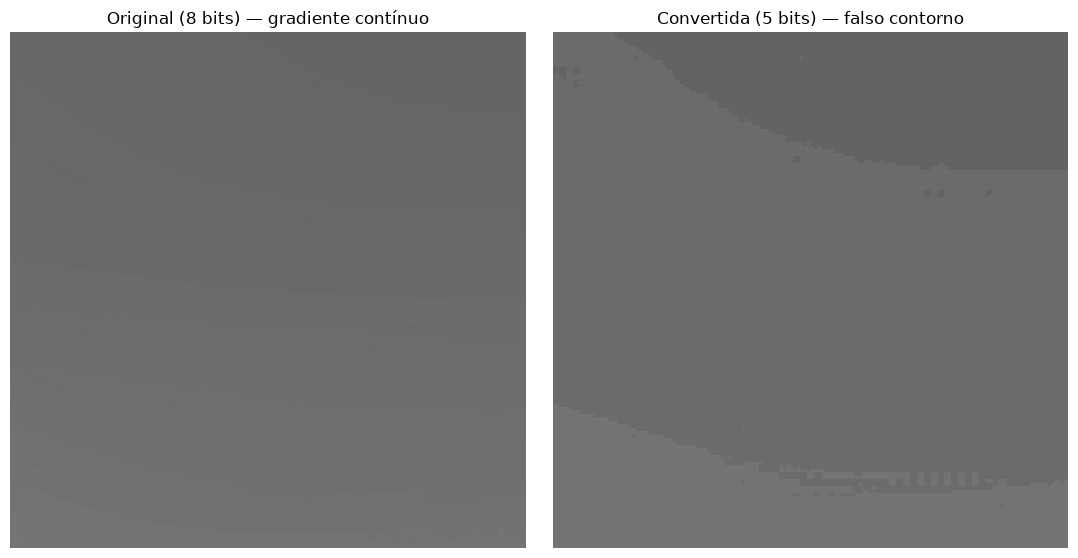

In [17]:
# --- Recorte ampliado: onde o falso contorno aparece ---

# Regiões de gradiente suave são as mais afetadas. Localizo a janela com menor
# variância local, que é onde a transição de tons é mais gradual.
JANELA = 150
passo = 50
melhor, menor_var = (0, 0), float("inf")

for y in range(0, altura - JANELA, passo):
    for x in range(0, largura - JANELA, passo):
        bloco = original[y:y + JANELA, x:x + JANELA]
        if bloco.std() < menor_var and bloco.std() > 1:
            menor_var, melhor = bloco.std(), (y, x)

y, x = melhor
print(f"Recorte em (linha={y}, coluna={x}), desvio padrão local = {menor_var:.2f}")

fig, eixos = plt.subplots(1, 2, figsize=(11, 5.5))
eixos[0].imshow(original[y:y + JANELA, x:x + JANELA],
                cmap="gray", vmin=0, vmax=MAXVAL_ORIGEM, interpolation="nearest")
eixos[0].set_title(f"Original ({BITS_ORIGEM} bits) — gradiente contínuo")
eixos[1].imshow(quant_b[y:y + JANELA, x:x + JANELA],
                cmap="gray", vmin=0, vmax=MAXVAL_DESTINO, interpolation="nearest")
eixos[1].set_title(f"Convertida ({BITS_DESTINO} bits) — falso contorno")
for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

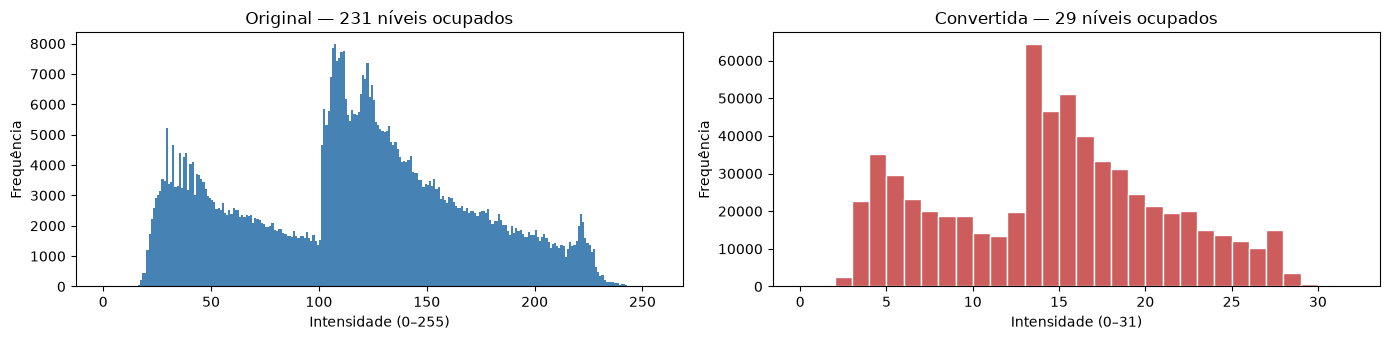

O histograma da convertida é discreto e esparso: as 256 barras finas da
original foram agrupadas em no máximo 32 barras largas.


In [18]:
# --- Histogramas comparados ---

fig, eixos = plt.subplots(1, 2, figsize=(14, 3.5))

eixos[0].hist(original.ravel(), bins=MAXVAL_ORIGEM + 1,
              range=(0, MAXVAL_ORIGEM + 1), color="steelblue", edgecolor="none")
eixos[0].set_title(f"Original — {np.unique(original).size} níveis ocupados")
eixos[0].set_xlabel("Intensidade (0–255)")

eixos[1].hist(quant_b.ravel(), bins=MAXVAL_DESTINO + 1,
              range=(0, MAXVAL_DESTINO + 1), color="indianred", edgecolor="white")
eixos[1].set_title(f"Convertida — {np.unique(quant_b).size} níveis ocupados")
eixos[1].set_xlabel("Intensidade (0–31)")

for ax in eixos:
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

print("O histograma da convertida é discreto e esparso: as 256 barras finas da")
print("original foram agrupadas em no máximo 32 barras largas.")

 Bits  Níveis       MSE   PSNR (dB)
-----------------------------------
    8     256      0.00         inf
    7     128      0.50       51.10
    6      64      1.53       46.27
    5      32      5.83       40.47
    4      16     24.06       34.32
    3       8    100.28       28.12
    2       4    772.15       19.25
    1       2   8120.52        9.03


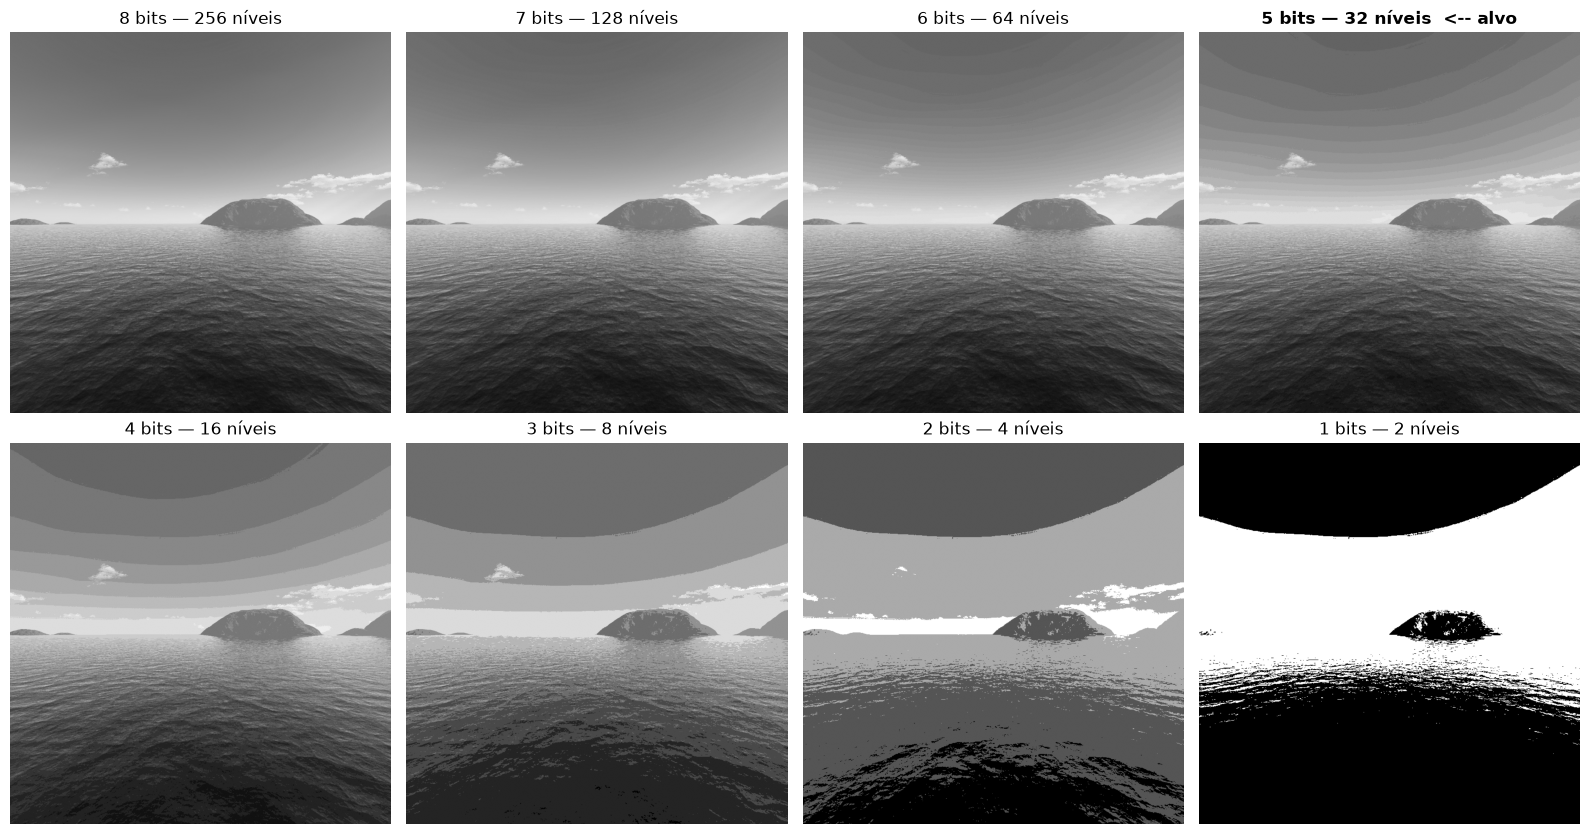

In [19]:
# --- Bônus: degradação progressiva de 8 até 1 bit ---

profundidades = [8, 7, 6, 5, 4, 3, 2, 1]
fig, eixos = plt.subplots(2, 4, figsize=(16, 8.5))

print(f"{'Bits':>5}{'Níveis':>8}{'MSE':>10}{'PSNR (dB)':>12}")
print("-" * 35)

for ax, bits in zip(eixos.ravel(), profundidades):
    mv = 2 ** bits - 1
    q = np.rint(original * (mv / MAXVAL_ORIGEM)).astype(np.int32)

    rec = np.rint(q * (MAXVAL_ORIGEM / mv))
    mse = float(((original - rec) ** 2).mean())
    psnr = 10 * np.log10(MAXVAL_ORIGEM ** 2 / mse) if mse > 0 else float("inf")

    ax.imshow(q, cmap="gray", vmin=0, vmax=mv)
    destaque = "  <-- alvo" if bits == BITS_DESTINO else ""
    ax.set_title(f"{bits} bits — {mv + 1} níveis{destaque}",
                 fontweight="bold" if bits == BITS_DESTINO else "normal")
    ax.axis("off")

    print(f"{bits:>5}{mv + 1:>8}{mse:>10.2f}{psnr:>12.2f}")

plt.tight_layout()
plt.show()

---

## 5. Conclusões

### Resultado

A imagem `EntradaEscalaCinza.pgm` (800 × 800, 8 bits) foi convertida para 5 bits
e gravada como `saida/SaidaEscalaCinza_5bits.pgm`, um arquivo PGM P2 válido com
`maxval = 31`, verificado por round-trip e pelo limite de 70 colunas.

### O fator de conversão

O fator adotado é **31/255 ≈ 0,12157**, aplicado com arredondamento ao inteiro
mais próximo. Comparado ao descarte direto dos 3 bits menos significativos
(`>> 3`), essa formulação apresentou menor MSE, menor erro máximo e viés
praticamente nulo — enquanto o truncamento escurece a imagem sistematicamente,
já que erra sempre para o mesmo lado.

### Sobre a perda

A conversão é irreversível: 8 níveis de entrada colapsam em cada nível de saída,
e nenhuma operação posterior recupera essa informação. A reexpansão para 255
usada nas comparações apenas devolve a imagem à escala original — o histograma
resultante continua tendo no máximo 32 barras.

O artefato característico é o **falso contorno** (*banding*): regiões de
gradiente suave, que na original variavam píxel a píxel, passam a exibir faixas
chapadas com degraus visíveis nas fronteiras. Por isso o recorte ampliado foi
tomado justamente na região de menor variância local — é onde o efeito é mais
evidente. Áreas de alta frequência (bordas, texturas) mascaram a quantização e
quase não denunciam a perda.

A série de 8 a 1 bit mostra que a degradação não é linear: até 6 bits a diferença
é praticamente imperceptível, aos 5 o *banding* começa a se manifestar em
gradientes, e abaixo de 4 a imagem se descaracteriza rapidamente. Esse
comportamento é o mesmo que a apostila ilustra ao comparar níveis crescentes de
perda na compressão JFIF.